# lab 8 - Knn Classification for Video data

##Date: 5/4/26
###Soledad Rodriguez



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

#Step 1 -- Load and Analyze Data

In [ ]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
video_store_file = '/content/drive/MyDrive/CI345_ML//data/Video_Store.csv'

orginal_vtable = pd.read_csv(video_store_file)
orginal_vtable.head(3)

Mounted at /content/drive


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No
2,3,F,32000,20,42,1.6,Comedy,No


In [ ]:
df = orginal_vtable.head(3)
df

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No
2,3,F,32000,20,42,1.6,Comedy,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Cust ID      3 non-null      int64  
 1   Gender       3 non-null      object 
 2   Income       3 non-null      int64  
 3   Age          3 non-null      int64  
 4   Rentals      3 non-null      int64  
 5   AvgPerVisit  3 non-null      float64
 6   Genre        3 non-null      object 
 7   Like         3 non-null      object 
dtypes: float64(1), int64(4), object(3)
memory usage: 324.0+ bytes


In [ ]:
df.dtypes

,0
Cust ID,int64
Gender,object
Income,int64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,object
Like,object


In [ ]:
df.isnull().sum()

,0
Cust ID,0
Gender,0
Income,0
Age,0
Rentals,0
AvgPerVisit,0
Genre,0
Like,0


In [ ]:

vtable = orginal_vtable
vtable['Income'] = vtable['Income'].astype(float)
vtable
vtable.dtypes

,0
Cust ID,int64
Gender,object
Income,float64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,object
Like,object


In [ ]:
print(orginal_vtable.dtypes)

Cust ID          int64
Gender          object
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre           object
Like            object
dtype: object


In [ ]:
print(df['Income'].describe())
print('---------------------------------------------')
df[['Income','Age','Rentals']].describe()


count        3.000000
mean     43666.666667
std      11060.440015
min      32000.000000
25%      38500.000000
50%      45000.000000
75%      49500.000000
max      54000.000000
Name: Income, dtype: float64
---------------------------------------------


,Income,Age,Rentals
count,3.000000,3.000000,3.000000
mean,43666.666667,26.000000,28.666667
std,11060.440015,6.557439,15.275252
min,32000.000000,20.000000,12.000000
25%,38500.000000,22.500000,22.000000
50%,45000.000000,25.000000,32.000000
75%,49500.000000,29.000000,37.000000
max,54000.000000,33.000000,42.000000


In [ ]:
df = orginal_vtable
df.head(2)

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000.0,25,32,2.5,Action,Yes
1,2,F,54000.0,33,12,3.4,Drama,No


#Step 2 -- Data Visualization

Genre
Drama     20
Action    18
Comedy    12
Name: count, dtype: int64
-----------------------------------


<Axes: title={'center': 'Numbers in Each Genre'}, xlabel='Genre'>

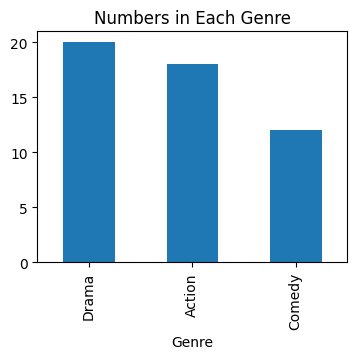

In [ ]:

res = df['Genre'].value_counts()
print(res)
print('-----------------------------------')
res.plot(kind = 'bar', figsize = (4,3), title = 'Numbers in Each Genre')

<Axes: title={'center': 'Income'}, ylabel='Frequency'>

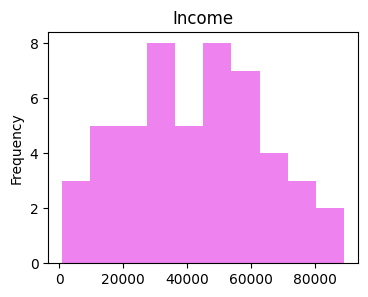

In [ ]:
df = orginal_vtable
res = df['Income']
res.plot(kind = 'hist', title = 'Income', color = 'violet', figsize = (4,3))

<Axes: title={'center': 'Numbers in like'}, xlabel='Like'>

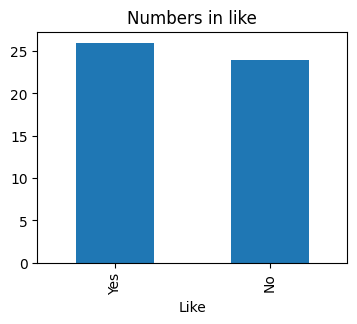

In [ ]:
res = df['Like'].value_counts()
res.plot(kind = 'bar', figsize = (4,3), title = 'Numbers in like')


Lab8 - Soledad Rodriguez


array([[<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Rentals'}>,
        <Axes: title={'center': 'AvgPerVisit'}>]], dtype=object)

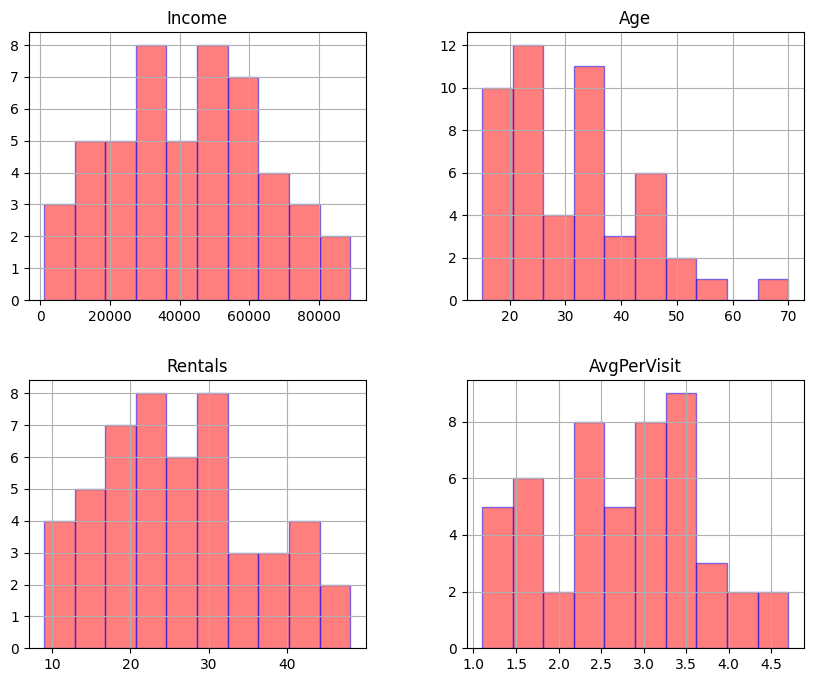

In [ ]:
print('Lab8 - Soledad Rodriguez')
df = orginal_vtable
res = df[['Income','Age','Rentals','AvgPerVisit']]

res.hist(alpha = 0.5, color = 'red', edgecolor = 'blue',figsize = (10,8))


#Step 3 -- Data Processing
##Converting categorical feature into numerical feature

In [ ]:
# Method 1 : Using LabelEncoder
# Problem: model may think numbers have order (0 < 1 < 2)
# Use mainly for target labels (y), not features

print('--------')
df = orginal_vtable
from sklearn.preprocessing import LabelEncoder

# All category feature need to transfer to numeric feature
encoder = LabelEncoder()
df= df.apply(encoder.fit_transform)
print(df.dtypes)
print(df.head(2))

# vs Method


print(df.dtypes)
df.head(2)

--------
Cust ID        int64
Gender         int64
Income         int64
Age            int64
Rentals        int64
AvgPerVisit    int64
Genre          int64
Like           int64
dtype: object
   Cust ID  Gender  Income  Age  Rentals  AvgPerVisit  Genre  Like
0        0       1      19    8       20           10      0     1
1        1       0      24   13        2           18      2     0
Cust ID        int64
Gender         int64
Income         int64
Age            int64
Rentals        int64
AvgPerVisit    int64
Genre          int64
Like           int64
dtype: object


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,0,1,19,8,20,10,0,1
1,1,0,24,13,2,18,2,0


#Step 4 -- KNN Classification

In [ ]:
# Current process data has not category
vtable_after_LabelEncoder = df
# Seperate data part
v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]
# Get target
v_target = vtable['Like']


print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(50, 6)
(50,)


,Gender,Income,Age,Rentals,AvgPerVisit,Genre
0,M,45000.0,25,32,2.5,Action
1,F,54000.0,33,12,3.4,Drama
2,F,32000.0,20,42,1.6,Comedy


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Ensure we use the numeric dummy-encoded data created in earlier cells
# We'll pull directly from df_use_dummies to be safe
features = df_use_dummies[['Income','Age','Rentals', 'AvgPerVisit','Gender_F', 'Genre_Action','Genre_Comedy','Genre_Drama']]
target = df_use_dummies['Like_Yes']

data_train, data_test, target_train, target_test = train_test_split(features, target, random_state=11, test_size=0.2)

print("Train shape:", data_train.shape)
print("Test shape:", data_test.shape)

# Step 4: Create a KNN classifier
n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights='distance')

# Training the KNN classifier
knn_classifier.fit(X=data_train, y=target_train)
print("Model trained successfully:", knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X=data_test)

# Step 6: Evaluation
print("\n--- Classification Report ---")
print(classification_report(target_test, predicted))

print('--- Confusion Matrix ---')
print(confusion_matrix(y_true=target_test, y_pred=predicted))

Train shape: (40, 8)
Test shape: (10, 8)
Model trained successfully: KNeighborsClassifier(n_neighbors=3, weights='distance')

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.43      1.00      0.60         3

    accuracy                           0.60        10
   macro avg       0.71      0.71      0.60        10
weighted avg       0.83      0.60      0.60        10

--- Confusion Matrix ---
[[3 4]
 [0 3]]


#Step 5 -- Using get_dummies using pandas

In [ ]:
# Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies
df = orginal_vtable
print(df.head(2))
gender_df= pd.get_dummies(df['Gender'])

v_matrix = pd.get_dummies(orginal_vtable)
print(v_matrix.dtypes)
print(v_matrix.head(2))

v_matrix = v_matrix.astype(int)
print(v_matrix.head(2))

# Problem : numberical features also changed !!!!


   Cust ID Gender   Income  Age  Rentals  AvgPerVisit   Genre Like
0        1      M  45000.0   25       32          2.5  Action  Yes
1        2      F  54000.0   33       12          3.4   Drama   No
Cust ID           int64
Income          float64
Age               int64
Rentals           int64
AvgPerVisit     float64
Gender_F           bool
Gender_M           bool
Genre_Action       bool
Genre_Comedy       bool
Genre_Drama        bool
Like_No            bool
Like_Yes           bool
dtype: object
   Cust ID   Income  Age  Rentals  AvgPerVisit  Gender_F  Gender_M  \
0        1  45000.0   25       32          2.5     False      True   
1        2  54000.0   33       12          3.4      True     False   

   Genre_Action  Genre_Comedy  Genre_Drama  Like_No  Like_Yes  
0          True         False        False    False      True  
1         False         False         True     True     False  
   Cust ID  Income  Age  Rentals  AvgPerVisit  Gender_F  Gender_M  \
0        1   45000   25  

In [ ]:

from pandas.core.indexes import category

#Only Convert Converting categoric feature to numerical feature
# Method 2 : Using get_dummies
category_cols = ['Gender','Genre', 'Like']

df_use_dummies = pd.get_dummies(df, columns = category_cols, dtype=int)
print(df_use_dummies.dtypes)

Cust ID           int64
Income          float64
Age               int64
Rentals           int64
AvgPerVisit     float64
Gender_F          int64
Gender_M          int64
Genre_Action      int64
Genre_Comedy      int64
Genre_Drama       int64
Like_No           int64
Like_Yes          int64
dtype: object


In [ ]:
df_use_dummies.shape

(50, 12)

In [ ]:

# Drop duplicated columns
print(df_use_dummies.shape)
df_use_dummies.head(2)


(50, 12)


,Cust ID,Income,Age,Rentals,AvgPerVisit,Gender_F,Gender_M,Genre_Action,Genre_Comedy,Genre_Drama,Like_No,Like_Yes
0,1,45000.0,25,32,2.5,0,1,1,0,0,0,1
1,2,54000.0,33,12,3.4,1,0,0,0,1,1,0


In [ ]:

# Current process data has not category
vtable = df_use_dummies
# Seperate data part
v_data = vtable[['Income','Age','Rentals', 'AvgPerVisit','Gender_F', 'Genre_Action','Genre_Comedy','Genre_Drama']]
# Get target
v_target = vtable['Like_Yes']


print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(50, 8)
(50,)


,Income,Age,Rentals,AvgPerVisit,Gender_F,Genre_Action,Genre_Comedy,Genre_Drama
0,45000.0,25,32,2.5,0,1,0,0
1,54000.0,33,12,3.4,1,0,0,1
2,32000.0,20,42,1.6,1,0,1,0


In [ ]:
# Seperate data and target, after use dummies

all_cols = df_use_dummies.columns
print(all_cols)

size = len(all_cols)
print(size)

data_cols = all_cols[0:(size-2)]
print(data_cols)
print(df_use_dummies.columns[0:(size-2)] )

# Seperate data part
# The indentation has been corrected and columns updated to match
#the one-hot encoded format.
v_data = df_use_dummies[data_cols]
v_data = vtable[['Income','Age','Rentals', 'AvgPerVisit','Gender_F', \
                 'Genre_Action','Genre_Comedy','Genre_Drama']]

# Get target
v_target = vtable['Like_Yes']

print('\nData shape:', v_data.shape)
print('Target shape:', v_target.shape)
display(v_data.head(3))

Index(['Cust ID', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Gender_F',
       'Gender_M', 'Genre_Action', 'Genre_Comedy', 'Genre_Drama', 'Like_No',
       'Like_Yes'],
      dtype='object')
12
Index(['Cust ID', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Gender_F',
       'Gender_M', 'Genre_Action', 'Genre_Comedy', 'Genre_Drama'],
      dtype='object')
Index(['Cust ID', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Gender_F',
       'Gender_M', 'Genre_Action', 'Genre_Comedy', 'Genre_Drama'],
      dtype='object')

Data shape: (50, 8)
Target shape: (50,)


,Income,Age,Rentals,AvgPerVisit,Gender_F,Genre_Action,Genre_Comedy,Genre_Drama
0,45000.0,25,32,2.5,0,1,0,0
1,54000.0,33,12,3.4,1,0,0,1
2,32000.0,20,42,1.6,1,0,1,0


In [ ]:
v_data.head(2)

,Income,Age,Rentals,AvgPerVisit,Gender_F,Genre_Action,Genre_Comedy,Genre_Drama
0,45000.0,25,32,2.5,0,1,0,0
1,54000.0,33,12,3.4,1,0,0,1


In [ ]:
v_target.head(2)

,Like_Yes
0,1
1,0


#Step 6 -- KNN Classification Again

In [ ]:
# After using use_dummies

# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = \
train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)


(40, 8)
(10, 8)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=3, weights='distance')


#Evaluation -- Use Label Encoder Method

In [ ]:
# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.43      1.00      0.60         3

    accuracy                           0.60        10
   macro avg       0.71      0.71      0.60        10
weighted avg       0.83      0.60      0.60        10

------ Confusion Matrix
[[3 4]
 [0 3]]


#Lab 9 -- Using Decision Tree

##Coverting categorical features using dummies


In [ ]:
#Data is already split to training and testing from previous classifier used.

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

data_train.head(2)


(40, 8)
(10, 8)
(40,)
(10,)


,Income,Age,Rentals,AvgPerVisit,Gender_F,Genre_Action,Genre_Comedy,Genre_Drama
14,68000.0,30,36,2.7,0,0,1,0
42,49000.0,28,48,3.3,1,0,0,1


#Apply decision Tree Classifier

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

#Step 4: Create Decisoin Tree
dt_classifier = DecisionTreeClassifier(max_depth=5)

#Training and decision classifier
dt_classifier.fit(X=data_train, y=target_train)
print(dt_classifier)

#Step 5: Testing
predicted = dt_classifier.predict(X=data_test)

#Step 6: Evaluation , Classification Report
print("\n--- Classification Report ---")
print(classification_report(target_test, predicted))

matrix = confusion_matrix(y_true=target_test, y_pred=predicted)
print('--- Confusion Matrix ---')
print(matrix)



DecisionTreeClassifier(max_depth=5)

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.60      1.00      0.75         3

    accuracy                           0.80        10
   macro avg       0.80      0.86      0.79        10
weighted avg       0.88      0.80      0.81        10

--- Confusion Matrix ---
[[5 2]
 [0 3]]



## Method 3 : Using HotOneEncoder


In [ ]:
#use scores method
score = knn_classifier.score(v_test_norm, target_test)
score

NameError: name 'v_test_norm' is not defined

In [ ]:
#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print(matrix)

[[3 4]
 [0 3]]


In [ ]:
#Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)